In [32]:
import pandas as pd
import numpy as np
import os
import datetime as dt

### Data frame creator

In [33]:
df_smog = pd.read_csv('../data/smog_raw.csv')

### Data frame shape

In [490]:
df_smog.shape

(1630, 12)

### Insert area column and get postal code area number

In [35]:
df_smog2.shape

### Data frame first look

In [509]:
df_smog

,NAME,STREET,POST_CODE,CITY,LONGITUDE,LATITUDE,HUMIDITY_AVG,PRESSURE_AVG,TEMPERATURE_AVG,PM10_AVG,PM25_AVG,TIMESTAMP
0,SZKO?A PODSTAWOWA IM. MARIANA FALSKIEGO W KRAS...,UL. SZKOLNA,63-522,KRASZEWICE,18.224030,51.515630,99.900000,1011.766667,19.166667,8.333333,4.606667,2026-07-01 00:00:00.0
1,SZKO?A PODSTAWOWA WE WRZ?SOWICACH,UL. SZKOLNA,32-040,WRZ?SOWICE,19.942820,49.961030,58.408333,978.891667,27.316667,11.525000,10.300000,2026-07-01 00:00:00.0
2,ZESP?? SZK?? NR 1 W PSZCZYNIE,UL. KAZIMIERZA WIELKIEGO,43-200,PSZCZYNA,18.945706,49.965883,99.900000,999.900000,25.933333,27.733333,16.193333,2026-07-01 00:00:00.0
3,ZESP?? SZK?? IM. POWSTA?C?W WIELKOPOLSKICH W J...,SZKOLNA,63-421,JANK?W PRZYGODZKI,17.788907,51.596172,99.900000,992.400000,16.400000,21.300000,11.150000,2026-07-01 00:00:00.0
4,SZKO?A PODSTAWOWA NR 7 IM. ?O?NIERZY WRZE?NIA ...,UL. M?CZENNIK?W O?WI?CIMSKICH,43-229,?WIKLICE,18.989839,49.971937,92.666667,986.333333,26.366667,27.633333,14.266667,2026-07-01 00:00:00.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1625,SZKO?A PODSTAWOWA IM.BOHATER?W WRZE?NIA 1939R....,KONOPNICKIEJ,34-240,JORDAN?W,19.834938,49.653449,81.545455,960.445455,23.745455,20.445455,20.190909,2026-07-01 00:00:00.0
1626,PRZEDSZKOLE NR 10 W PIASECZNIE,NADARZY?SKA,05-500,PIASECZNO,21.017680,52.072370,51.491667,1006.391667,26.358333,3.325000,3.050000,2026-07-01 00:00:00.0
1627,SZKO?A PODSTAWOWA IM. JANA PAW?A II W WILCZKOWIE,UL. MIKO?AJA KOPERNIKA,55-020,WILCZK?W,16.989396,50.966512,71.483333,998.225000,25.333333,9.641667,9.375000,2026-07-01 00:00:00.0
1628,PRZEDSZKOLE SAMORZ?DOWE W GOLI,NaN,63-800,GOLA,16.944640,51.870920,82.033333,1002.358333,22.691667,4.925000,4.925000,2026-07-01 00:00:00.0


### Set variables

In [37]:
area_dict = {
    "00-09": "mazowieckie",
    "10-19": "warminsko-mazurskie",
    "20-29": "lubelskie",
    "30-39": "malopolskie",
    "50-59": "dolnoslaskie",
    "60-69": "wielkopolskie",
    "70-79": "zachodniopomorskie",
    "80-89": "pomorskie",
    "90-99": "lodzkie"
}
smog_columns = ['LONGITUDE', 'LATITUDE', 'HUMIDITY_AVG', 'PRESSURE_AVG', 'TEMPERATURE_AVG', 'PM10_AVG', 'PM25_AVG']

### Format float values with precission to 1

In [38]:
for x in smog_columns:
    df_smog[f"{x}"] = df_smog[f"{x}"].round(1)

Wyciągamy sam czas (Format: GG:MM:SS)

In [519]:
df_smog['TYLKO_CZAS'] = df_smog['TIMESTAMP_DATETIME'].dt.time

In [ ]:
df_smog2.shape

Usuwamy kolumnę pomocniczą

In [520]:
df_smog

Sortowanie po kodzie pocztowym

In [41]:
for x in smog_columns:
    df_smog[f"{x}"].isna()

,NAME,STREET,POST_CODE,CITY,LONGITUDE,LATITUDE,HUMIDITY_AVG,PRESSURE_AVG,TEMPERATURE_AVG,PM10_AVG,PM25_AVG,TIMESTAMP,TYLKO_DATA,TYLKO_CZAS
592,ZESP?? SZK?? NR4-SZKO?A PODSTAWOWA W SOPOTNI W...,NaN,34-340,SOPOTNIA WIELKA,19.296044,49.592517,100.000000,1100.000000,-40.000,30.616667,26.558333,2026-07-01 00:00:00.0,2026-07-01,00:00:00
52,SZKO?A PODSTAWOWA IM. TADEUSZA MAZOWIECKIEGO W...,SZKOLNA,55-040,TYNIEC MA?Y,16.909195,51.021600,67.800000,1019.160000,2.500,39.960000,21.930000,2026-07-01 00:00:00.0,2026-07-01,00:00:00
71,SZKO?A PODSTAWOWA IM. TADEUSZA KO?CIUSZKI W MU...,3-GO MAJA,37-514,MUNINA,22.725977,49.997936,56.500000,996.300000,6.800,68.400000,42.610000,2026-07-01 00:00:00.0,2026-07-01,00:00:00
80,SZKO?A PODSTAWOWA IM. MARII SK?ODOWSKIEJ-CURIE...,KAW?CZYN,62-704,KAW?CZYN,18.531260,51.908730,91.880000,1014.650000,8.930,28.280000,16.420000,2026-07-01 00:00:00.0,2026-07-01,00:00:00
86,ZESP?? EDUKACYJNY W KOLSKU,PIASTOWSKA,67-415,KOLSKO,15.961961,51.960693,88.340000,1020.570000,9.940,37.830000,22.350000,2026-07-01 00:00:00.0,2026-07-01,00:00:00
1303,SZKO?A PODSTAWOWA IM. OJCA ?WI?TEGO JANA PAW?A...,UL. WITOSA,33-131,??G TARNOWSKI,20.928012,50.092030,53.933333,996.766667,10.000,14.783333,15.466667,2026-07-01 00:00:00.0,2026-07-01,00:00:00
1387,SZKO?A PODSTAWOWA EKOLA WROC?AW,UL. ZIELI?SKIEGO,53-534,WROC?AW,17.020853,51.097829,64.050000,985.083333,10.000,16.058333,15.316667,2026-07-01 00:00:00.0,2026-07-01,00:00:00
96,SZKO?A PODSTAWOWA NR 1 IM. STRAJKU DZIECI KO?M...,GLINKI,63-720,KO?MIN WIELKOPOLSKI,17.456510,51.825660,88.500000,1007.100000,13.300,19.500000,11.760000,2026-07-01 00:00:00.0,2026-07-01,00:00:00
1287,SZKO?A PODSTAWOWA IM. JANA PAW?A II W BA?YNACH,NaN,11-130,BA?YNY,20.042061,54.132021,81.375000,1015.358333,15.925,2.641667,1.891667,2026-07-01 00:00:00.0,2026-07-01,00:00:00
3,ZESP?? SZK?? IM. POWSTA?C?W WIELKOPOLSKICH W J...,SZKOLNA,63-421,JANK?W PRZYGODZKI,17.788907,51.596172,99.900000,992.400000,16.400,21.300000,11.150000,2026-07-01 00:00:00.0,2026-07-01,00:00:00


Mapa braków

<Axes: >

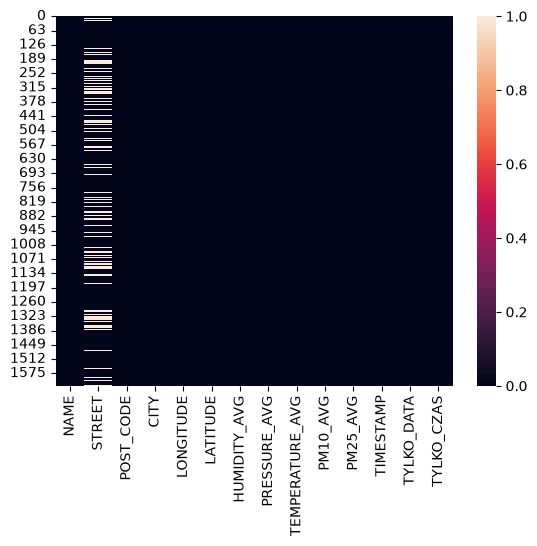

In [531]:
sns.heatmap(df_smog.isna())

### Save dataframe to csv file

In [43]:
ts = dt.datetime.now().strftime("%Y%m%d_%H-%M")
df_smog.to_csv(f"../tests/smog_raw{ts}.csv", index=False)
df_smog2.to_csv(f"../tests/smog2_raw{ts}.csv", index=False)